<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install pycountry pycountry-convert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 21.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 16.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.8 MB/s eta 0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 9.1 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 77.2 MB/s eta 0:00:00


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
## Write your code here
print(df.columns)
print(df.dtypes)
print(df.info())

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)
ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None


### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
## Write your code here
for col in df.columns:
    missing = df[col].isna().sum()
    print(col , ':' , missing)

ResponseId : 0
MainBranch : 0
Age : 0
Employment : 0
RemoteWork : 10631
Check : 0
CodingActivities : 10971
EdLevel : 4653
LearnCode : 4949
LearnCodeOnline : 16200
TechDoc : 24540
YearsCode : 5568
YearsCodePro : 13827
DevType : 5992
OrgSize : 17957
PurchaseInfluence : 18031
BuyNewTool : 20256
BuildvsBuy : 22079
TechEndorse : 21769
Country : 6507
Currency : 18753
CompTotal : 31697
LanguageHaveWorkedWith : 5692
LanguageWantToWorkWith : 9685
LanguageAdmired : 14565
DatabaseHaveWorkedWith : 15183
DatabaseWantToWorkWith : 22879
DatabaseAdmired : 26880
PlatformHaveWorkedWith : 23071
PlatformWantToWorkWith : 30905
PlatformAdmired : 34060
WebframeHaveWorkedWith : 20276
WebframeWantToWorkWith : 26902
WebframeAdmired : 30494
EmbeddedHaveWorkedWith : 43223
EmbeddedWantToWorkWith : 47837
EmbeddedAdmired : 48704
MiscTechHaveWorkedWith : 25994
MiscTechWantToWorkWith : 32473
MiscTechAdmired : 35841
ToolsTechHaveWorkedWith : 12955
ToolsTechWantToWorkWith : 19353
ToolsTechAdmired : 21440
NEWCollabToolsH

In [5]:
#make a new dataframe where we will fill missing values
df_clean = df.copy()
#fill JobSat with distribution based imputation
import numpy as np
proportion_j = df['JobSat'].value_counts(normalize = True)
missing_j = df['JobSat'].isna()
df_clean.loc[missing_j , 'JobSat'] = np.random.choice(proportion_j.index , size = missing_j.sum() , p = proportion_j.values)

print('missing values in original:' , df['JobSat'].isna().sum())
print('missing values in df_clean:' , df_clean['JobSat'].isna().sum())

missing values in original: 36311
missing values in df_clean: 0


In [6]:
#replace inconsistent values in YearsCodePro
df_clean['YearsCodePro'] = df_clean['YearsCodePro'].replace({'Less than 1 year' : 0.5 , 'More than 50 years' : 51})
#convert to numeric values
df_clean['YearsCodePro'] = pd.to_numeric(df_clean['YearsCodePro'] , errors = 'coerce')
#fill missing values with median
median_ypc = df_clean['YearsCodePro'].median()
df_clean['YearsCodePro'] = df_clean['YearsCodePro'].fillna(median_ypc)
print('missing values:' , df_clean['YearsCodePro'].isna().sum())

missing values: 0


In [7]:
#fill missing values in RemoteWork
proportion_r = df['RemoteWork'].value_counts(normalize = True)
missing_r = df['RemoteWork'].isna()
df_clean.loc[missing_r , 'RemoteWork'] = np.random.choice(proportion_r.index , size = missing_r.sum() , p = proportion_r.values)
print('missing values in original df:' , df['RemoteWork'].isna().sum())
print('missing values in df_clean:' , df_clean['RemoteWork'].isna().sum())

missing values in original df: 10631
missing values in df_clean: 0


In [8]:
#fill missing values in Country
proportion_c = df['Country'].value_counts(normalize = True)
missing_c = df['Country'].isna()
df_clean.loc[missing_c , 'Country'] = np.random.choice(proportion_c.index , size = missing_c.sum() , p = proportion_c.values)
print('missing values in original df:' , df['Country'].isna().sum())
print('missing values in df_clean:' , df_clean['Country'].isna().sum())

missing values in original df: 6507
missing values in df_clean: 0


In [65]:
#fill missing values in EdLevel
proportion_e = df['EdLevel'].value_counts(normalize = True)
missing_e = df['EdLevel'].isna()
df_clean.loc[missing_e , 'EdLevel'] = np.random.choice(proportion_e.index , size = missing_e.sum() , p = proportion_e.values)
print('missing values in original df:' , df['EdLevel'].isna().sum())
print('missing values in df_clean:' , df_clean['EdLevel'].isna().sum())

missing values in original df: 4653
missing values in df_clean: 0


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [9]:
## Write your code here
print(df_clean['Employment'].value_counts())
print(df_clean['JobSat'].value_counts())
print(df_clean['YearsCodePro'].value_counts())

Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking for work;Independent contra

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


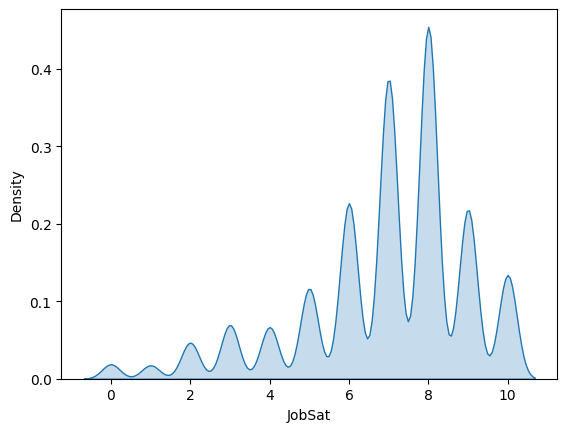

In [10]:
## Looking at the KDE plot we can see that the level of job satisfaction that most people have is mostly concentrated between 6 and 10, with most people at around a 7 or 8
#so either people are quite satisfied with their coding jobs in most cases, or are unlikely to give a meaningfully honest response on their satisfaction in this kind of environment.
sns.kdeplot(data = df_clean['JobSat'] , fill = True)
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


In [11]:
## Write your code here
Lworkedwith = df_clean['LanguageHaveWorkedWith'].str.split(';').explode().value_counts()
Lworkedwith

LanguageHaveWorkedWith
JavaScript                 37492
HTML/CSS                   31816
Python                     30719
SQL                        30682
TypeScript                 23150
Bash/Shell (all shells)    20412
Java                       18239
C#                         16318
C++                        13827
C                          12184
PHP                        10951
PowerShell                  8328
Go                          8103
Rust                        7559
Kotlin                      5665
Lua                         3728
Dart                        3594
Assembly                    3233
Ruby                        3147
Swift                       2829
R                           2595
Visual Basic (.Net)         2499
MATLAB                      2378
VBA                         2248
Groovy                      2004
Scala                       1547
Perl                        1482
GDScript                    1402
Objective-C                 1283
Elixir              

In [12]:
Lwantwork = df_clean['LanguageWantToWorkWith'].str.split(';').explode().value_counts()
Lwantwork

LanguageWantToWorkWith
Python                     25047
JavaScript                 23774
SQL                        22400
HTML/CSS                   20721
TypeScript                 20239
Rust                       17232
Go                         13837
Bash/Shell (all shells)    13744
C#                         12921
C++                        10873
Java                       10668
C                           8275
Kotlin                      7379
PHP                         5745
PowerShell                  4287
Swift                       3877
Dart                        3709
Zig                         3688
Lua                         3322
Assembly                    3007
Elixir                      2895
Ruby                        2774
Haskell                     2221
R                           2177
Scala                       1790
GDScript                    1667
Clojure                     1331
F#                          1272
Julia                       1263
Lisp                

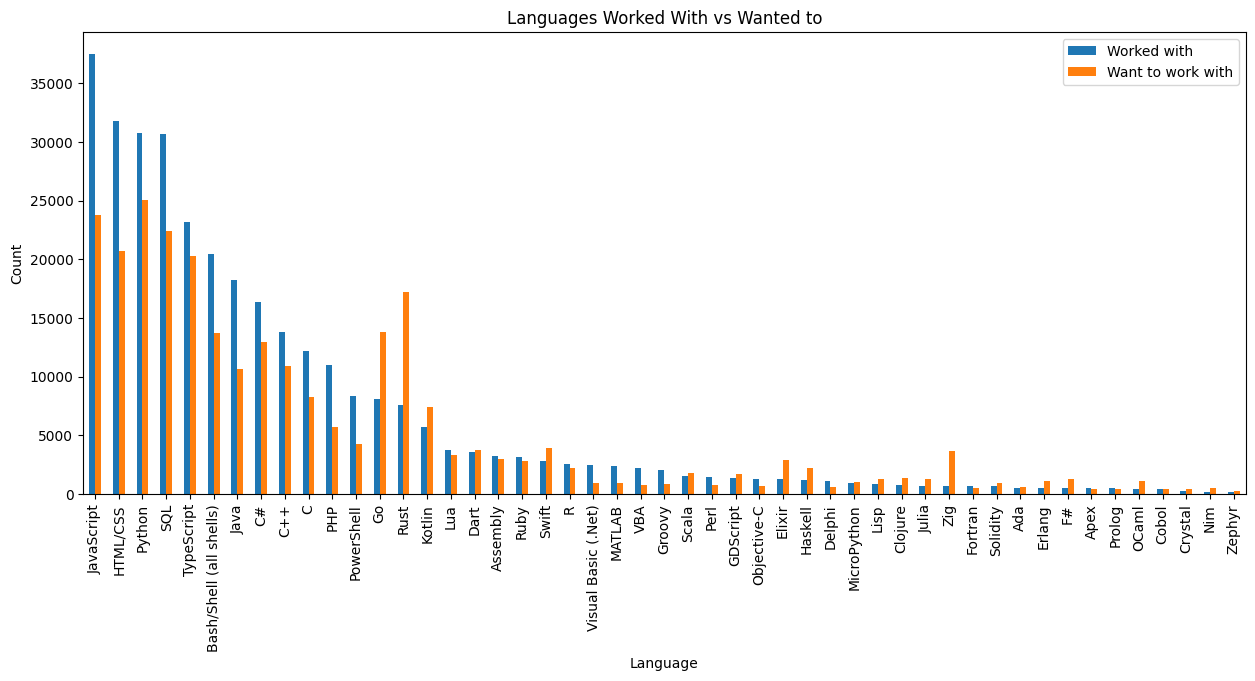

In [13]:
df_langwork = pd.DataFrame({'Worked with' : Lworkedwith , 'Want to work with' : Lwantwork}).fillna(0)
df_langwork = df_langwork.sort_values(by = 'Worked with' , ascending = False)

df_langwork.plot(kind = 'bar' , figsize = (15 , 6))
plt.xlabel('Language')
plt.ylabel('Count')
plt.title('Languages Worked With vs Wanted to')
plt.xticks(rotation=90)
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [14]:
## Create a more general regional column from df_clean['Country']
import pycountry_convert as pc
#create regions to be used in new column
continent_map = {'NA' : 'North America' , 'SA' : 'South America' , 'EU' : 'Europe' , 'AS' : 'Asia' , 'AF' : 'Africa' , 'OC' : 'Oceania'}
#create exception storage list for manual inspection
exceptions = []
#create a function to convert country names in df_clean['Country'] to new regions
def get_continent(country_name):

    try:
        country_code = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_code)

        return continent_map[continent_code]

    except:
        exceptions.append(country_name)
        return pd.NA

#apply funtion to the entire column
df_clean['Region'] = df_clean['Country'].apply(get_continent)
#check exceptions
pd.Series(exceptions).value_counts()

Iran, Islamic Republic of...            460
Hong Kong (S.A.R.)                      158
Venezuela, Bolivarian Republic of...     79
Republic of Korea                        62
Nomadic                                  48
Kosovo                                   19
Congo, Republic of the...                 9
Libyan Arab Jamahiriya                    4
Micronesia, Federated States of...        1
Name: count, dtype: int64

In [15]:
#manually correct naming inconsistencies
country_fixes = {'Congo, Republic of the...' : 'Congo',
 'Hong Kong (S.A.R.)' : 'Hong Kong',
 'Iran, Islamic Republic of...' : 'Iran',
 'Kosovo' : 'Kosovo',
 'Libyan Arab Jamahiriya' : 'Libya',
 'Micronesia, Federated States of...' : 'Micronesia',
 'Nomadic' : pd.NA,
 'Republic of Korea' : 'South Korea',
 'Venezuela, Bolivarian Republic of...' : 'Venezuela'}

df_clean['Country'] = df_clean['Country'].replace(country_fixes)

#reapply the funtion
exceptions = []
df_clean['Region'] = df_clean['Country'].apply(get_continent)
#check exceptions
pd.Series(exceptions).value_counts()
#manually assign kosovo to europe
df_clean.loc[df_clean['Country'] == 'Kosovo', 'Region'] = 'Europe'

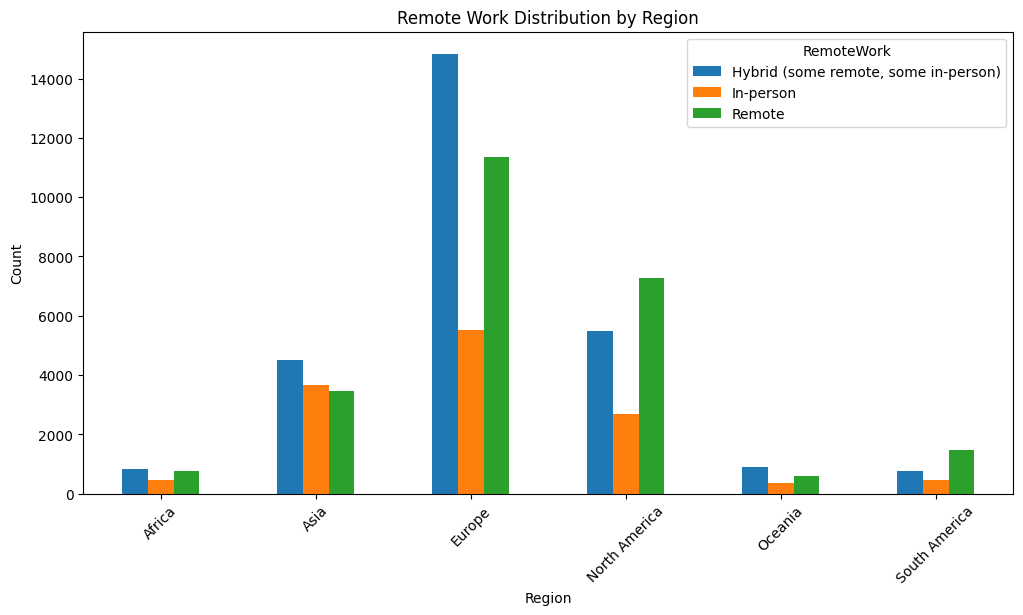

In [16]:
#visualize distribution of remotework by region
remote_region = pd.crosstab(df_clean['Region'] , df_clean['RemoteWork'])
remote_region.plot(kind = 'bar' , figsize = (12 , 6))

plt.xlabel('Region')
plt.ylabel('Count')
plt.title('Remote Work Distribution by Region')
plt.xticks(rotation=45)
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


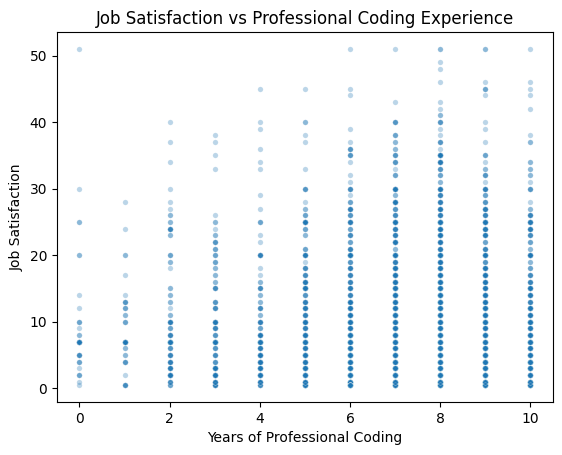

In [58]:
##replace inconsistent values in ypc and convert to numeric
df_clean['YearsCodePro'] = df_clean['YearsCodePro'].replace({'Less than 1 year' : 0.5 , 'More than 50 years' : 51})
df_clean['YearsCodePro'] = pd.to_numeric(df_clean['YearsCodePro'] , errors = 'coerce')
#create a sample of the data (since there are 65000+ responses a scatterplot would just be full of dots)
sample_df = df_clean.sample(n = 5000 , random_state = 42)
#visualize relationship
sns.scatterplot(data = sample_df , x = 'JobSat' , y = 'YearsCodePro' , alpha = 0.3 , s = 15)
plt.title('Job Satisfaction vs Professional Coding Experience')
plt.xlabel('Years of Professional Coding')
plt.ylabel('Job Satisfaction')
plt.show()

In [60]:
#calculate correlation coefficients - The trend is extremely weak, there almost zero linear or monotonic correlation between these two values.
#job satisfaction is probably more influenced by other categories.
print('pearson coeff:')
print(df_clean[['JobSat', 'YearsCodePro']].corr(method = 'pearson'))
print('spearman coeff:')
print(df_clean[['JobSat', 'YearsCodePro']].corr(method = 'spearman'))

pearson coeff:
                JobSat  YearsCodePro
JobSat        1.000000      0.053693
YearsCodePro  0.053693      1.000000
spearman coeff:
                JobSat  YearsCodePro
JobSat        1.000000      0.059646
YearsCodePro  0.059646      1.000000


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


In [68]:
##create new column with standardized employment values
def clean_employ(value):
    if pd.isna(value):
        return 'Unknown'

    value = value.lower()

    if 'employed, full-time' in value:
        return 'Employed, full-time'

    elif 'employed, part-time' in value:
        return 'Employed, part-time'

    elif 'self-employed' in value or 'freelancer' in value:
        return 'Self-employed'
        
    elif 'student' in value:
        return 'Student'

    elif 'not employed' in value:
        return 'Unemployed'

df_clean['EmploymentGrouped'] = df_clean['Employment'].apply(clean_employ)
df_clean['EmploymentGrouped'].value_counts()

EmploymentGrouped
Employed, full-time    45162
Student                 6482
Self-employed           6047
Employed, part-time     3639
Unemployed              3036
Name: count, dtype: int64

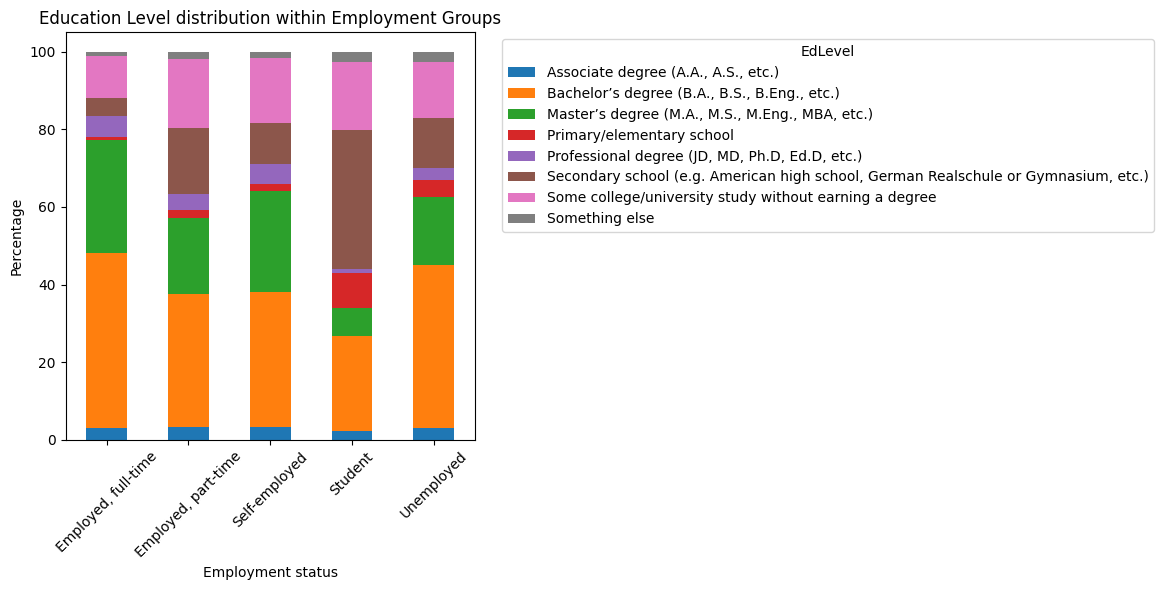

In [77]:
#cross-tab employment and edlevel (normalized values work better here since the overwhelming majority of responses are employed full-time)
emed_crosstab = pd.crosstab(df_clean['EmploymentGrouped'] , df_clean['EdLevel'] , normalize = 'index') * 100
#plot relationship
emed_crosstab.plot(kind = 'bar' , stacked = True , figsize = (12 , 6))
plt.xlabel('Employment status')
plt.ylabel('Percentage')
plt.title('Education Level distribution within Employment Groups')
plt.xticks(rotation=45)
plt.legend(title = 'EdLevel' , bbox_to_anchor=(1.05, 1) , loc = 'upper left')
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [79]:
## Write your code here
df_clean.to_csv('cleaned_survey_data.csv' , index = False)
df_test = pd.read_csv('cleaned_survey_data.csv')
df_test.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,Region,EmploymentGrouped
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,North America,"Employed, full-time"
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,7.0,Europe,"Employed, full-time"
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,7.0,Europe,"Employed, full-time"
3,4,I am learning to code,18-24 years old,"Student, full-time",Remote,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,Too long,Easy,NaN,6.0,North America,Student
4,5,I am a developer by profession,18-24 years old,"Student, full-time",Remote,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,Too short,Easy,NaN,6.0,Europe,Student


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
